<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day11_hierarchical_cluster(2/25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X,_= make_blobs(n_samples=50,centers=3)


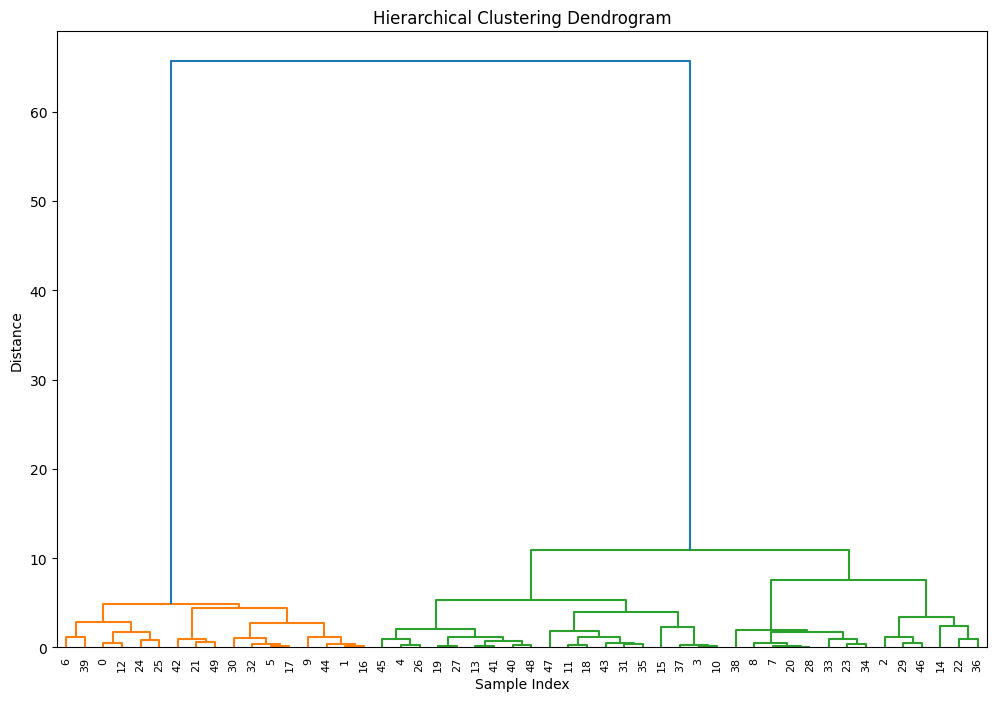

In [ ]:
plt.figure(figsize=(12,8)) #width =12 inches, Height = 8 inches
Z= linkage(X,method='ward')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

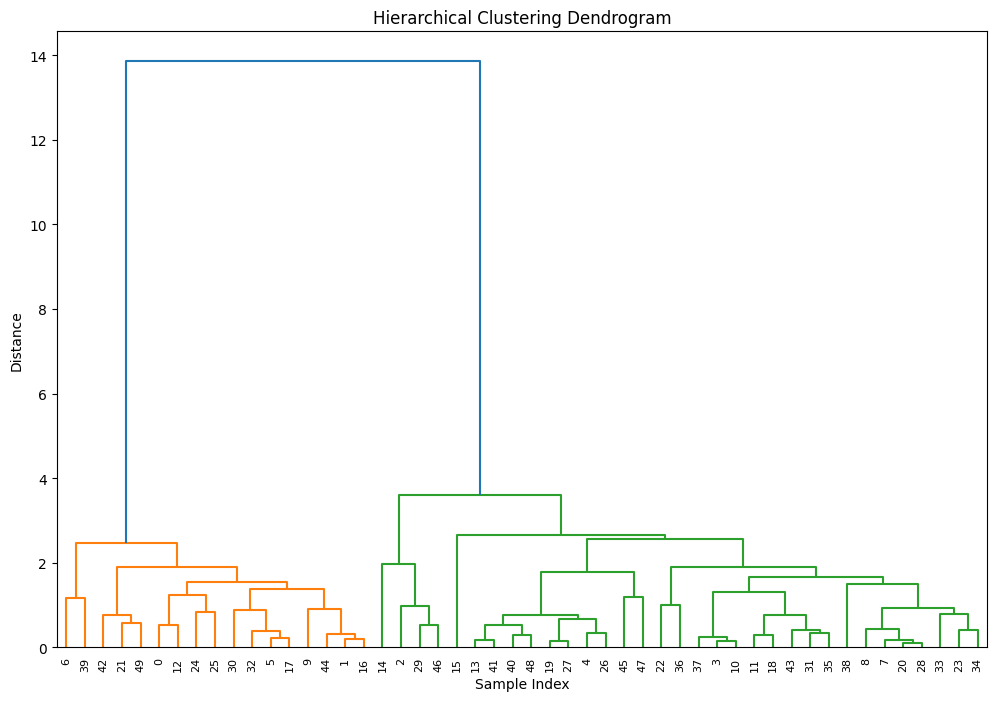

In [ ]:
plt.figure(figsize=(12,8)) #width =12 inches, Height = 8 inches
Z= linkage(X,method='centroid')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

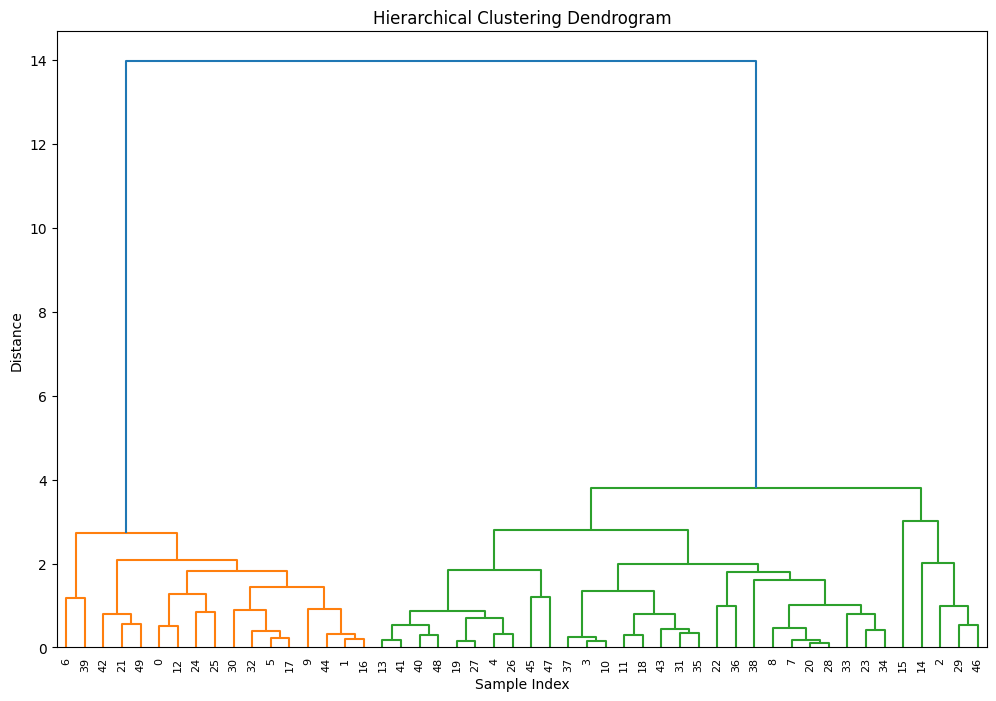

In [ ]:
plt.figure(figsize=(12,8)) #width =12 inches, Height = 8 inches
Z= linkage(X,method='average')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

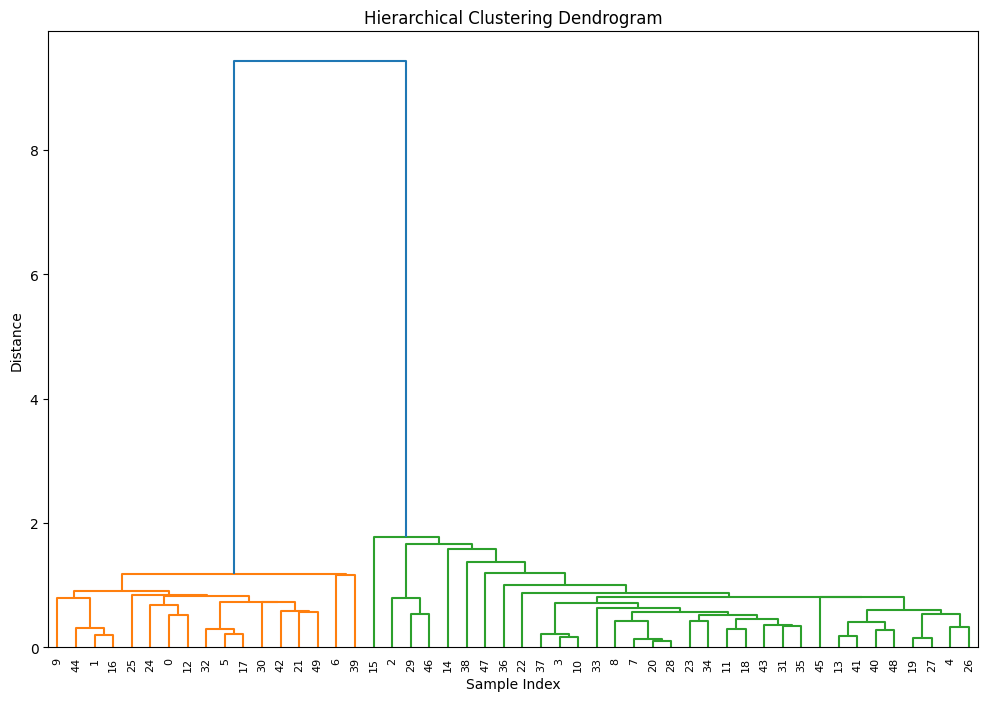

In [ ]:
plt.figure(figsize=(12,8)) #width =12 inches, Height = 8 inches
Z= linkage(X,method='single')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

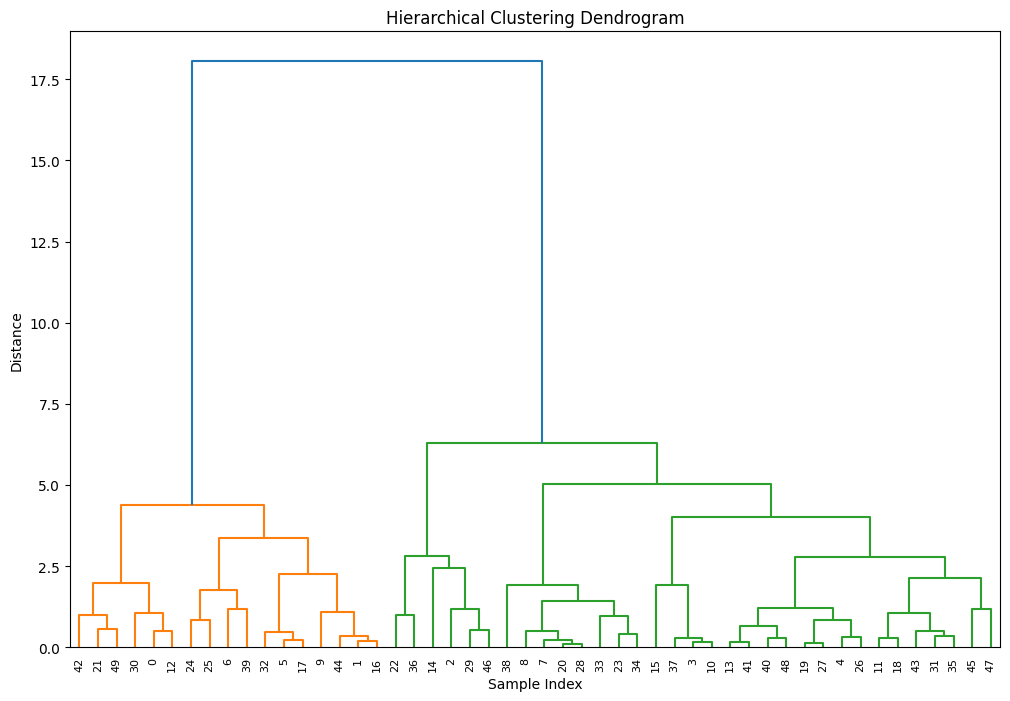

In [ ]:
plt.figure(figsize=(12,8)) #width =12 inches, Height = 8 inches
Z= linkage(X,method='complete')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

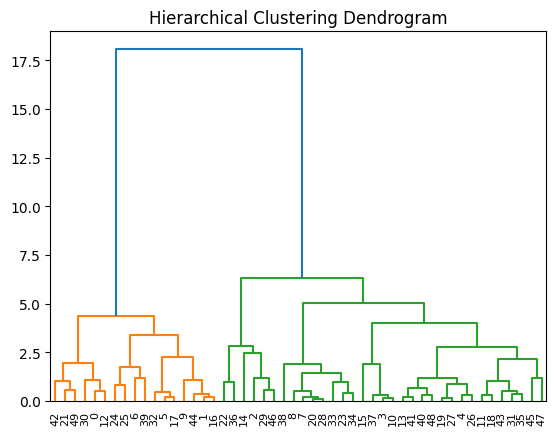

In [ ]:
z = linkage( X,method='ward')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.5 MB/s eta 0:00:00


In [ ]:
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

#Generate sample data
X,_=make_blobs(n_samples=30,centers=3,n_features=2,
               cluster_std=0.8,random_state=42)

#Compute linkage(using ward's method as default)
Z = linkage(X, method='ward')

def plot_cluster(n_clusters):
  """ Plot dendrogram with cut and resulting clusters"""

  #Get clusters
  clusters = fcluster(Z,n_clusters,criterion='maxclust')

  #Create figure with two subplots
  fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

  #Plot 1: dendrogram with cut line
  dendrogram(Z,ax=ax1)

  #find the height that gives exactly n_clusters
  #the cut height is the distance at the (n_clusters-1)th merge from the top
  cut_height = Z[-(n_clusters-1),2] if n_clusters > 1 else Z[-1,2]
  ax1.axhline(y=cut_height, color ='red', linestyle='--',linewidth=2,
              label=f'Cut for{n_clusters} clusters')
  ax1.set_title(f'Dendogram - Cut for {n_clusters} Clusters')
  ax1.set_Xlabel('Sample index')
  ax1.set_ylabel('Distance')
  ax1.legend()

  #plot 2: Resulting cluster in 2d

  scatter = ax2.scatter(X[:,0],X[:,1],c=clusters,cmap='viridis',s=100)
  ax2.set_title(f'Resulting clusters (n={n_clusters})')
  ax2.set_xlabel('Feature 1')
  ax2.set_ylabel('Feature 2')
  plt.colorbar(scatter,ax=ax2,label='Cluster ID')

  plt.tight_layout()
  plt.show()

  #show cluster sizes
  unique, counts =np.unique(clusters,return_counts=True)
  print(f"\nCluster sizes:")
  for cluster_id, count in zip(unique,counts):
    print(f"Cluster {cluster_id}:{count} Points")

  #create interactive slider
  interact(plot_clusters,n_clusters=IntSlider(min=2,max=10,step=1,value=3,
                                  description='Number of Clusters:') );


In [ ]:
#correct code
from ipywidgets import interact, IntSlider
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
X, _ = make_blobs(
    n_samples=30,
    centers=3,
    n_features=2,
    cluster_std=0.8,
    random_state=42
)

# Compute linkage
Z = linkage(X, method='ward')

def plot_cluster(n_clusters):
    """Plot dendrogram with cut and resulting clusters"""

    clusters = fcluster(Z, n_clusters, criterion='maxclust')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Dendrogram
    dendrogram(Z, ax=ax1)

    cut_height = Z[-(n_clusters-1), 2] if n_clusters > 1 else Z[-1, 2]

    ax1.axhline(
        y=cut_height,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Cut for {n_clusters} clusters'
    )

    ax1.set_title(f'Dendrogram - Cut for {n_clusters} Clusters')
    ax1.set_xlabel('Sample index')
    ax1.set_ylabel('Distance')
    ax1.legend()

    # Scatter plot
    scatter = ax2.scatter(
        X[:, 0],
        X[:, 1],
        c=clusters,
        cmap='viridis',
        s=100
    )

    ax2.set_title(f'Resulting Clusters (n={n_clusters})')
    ax2.set_xlabel('Feature 1')
    ax2.set_ylabel('Feature 2')

    plt.colorbar(scatter, ax=ax2, label='Cluster ID')

    plt.tight_layout()
    plt.show()

    # Cluster sizes
    unique, counts = np.unique(clusters, return_counts=True)

    print("\nCluster Sizes:")
    for cluster_id, count in zip(unique, counts):
        print(f"Cluster {cluster_id}: {count} Points")

# Interactive slider
interact(
    plot_cluster,
    n_clusters=IntSlider(
        min=2,
        max=10,
        step=1,
        value=3,
        description='Clusters:'
    )
)

interactive(children=(IntSlider(value=3, description='Clusters:', max=10, min=2), Output()), _dom_classes=('wi…

<function __main__.plot_cluster(n_clusters)>